# Testu garbiketa: NLP

## 🪇 1. Testuko zarata kendu. Noise removing (Beautiful Soup)
Jarraituko diren pausuak:
1. Dokumentuko testu guztia string batean sartu (nahi izanez gero)
2. letra xehez idatzi, url-ak kendu, karaktere bereziak eta hitzen arteko zenbakiak ezabatu.
3. Ingleseko murrizketak kendu.

In [113]:
# hasierako inportak
from bs4 import BeautifulSoup
import requests
import re

In [114]:
# Wikipedia requires proper User-Agent header to respect their robot policy
# User-Agent identifies our request and shows we're not a malicious bot
headers = {
    'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

url_english = 'https://en.wikipedia.org/wiki/Marxism'

# Make request WITH headers (important for Wikipedia)
response = requests.get(url_english, headers=headers)

# Beautiful soup to parse HTML
soup = BeautifulSoup(response.text, 'html.parser')

# Get main content only (avoiding navigation, footer, etc.)
paragraphs = soup.find_all('p')

In [162]:
#wikipediak dialog_header_subtitle bueltatzen digu, izatez, benetako weborrian ez dagoena
paragraphs.pop(1)
paragraphs.pop(0)

'marx addressed the alienation and exploitation of the working class the capitalist mode of production and historical materialism he is famous for analysing history in terms of class struggle summarised in the initial line introducing the communist manifesto the history of all hitherto existing society is the history of class struggles'

In [116]:
len(paragraphs)

84

### 1.1. letra xehez idatzi, url-ak kendu, karaktere bereziak eta hitzen arteko zenbakiak ezabatu.

In [117]:
def testu_garbiketa(testua):
    # lower case
    testua = testua.lower()

    # remove URLs
    testua = re.sub(r"http\S+|www\.\S+", "", testua)

    # remove words containing numbers
    testua = re.sub(r"\w*\d\w*", "", testua)

    # remove special characters (keep only letters and spaces)
    testua = re.sub(r"[^a-z\s]", "", testua)

    # remove extra whitespace
    testua = re.sub(r"\s+", " ", testua).strip()

    return testua

# testua paragrafoka
paragraphs = [testu_garbiketa(p.get_text()) for p in paragraphs]
paragraphs[2]

'marxist analysis views a societys economic mode of production as the foundation of its social political and intellectual life a concept known as the base and superstructure model in its critique of capitalism marxism posits that the ruling class the bourgeoisie who own the means of production systematically exploit the working class the proletariat who must sell their labour power to survive this relationship according to marx leads to alienation periodic economic crises and escalating class conflict marx theorised that these internal contradictions would fuel a proletarian revolution leading to the overthrow of capitalism and the establishment of a socialist mode of production for marxists this transition represents a necessary step towards a classless stateless communist society'

In [163]:
# Decontract English contractions
contractions = {
    "ain't": "are not", "aren't": "are not", "can't": "can not", "can't've": "can not have",
    "could've": "could have", "couldn't": "could not", "couldn't've": "could not have",
    "didn't": "did not", "doesn't": "does not", "don't": "do not", "hadn't": "had not",
    "hadn't've": "had not have", "hasn't": "has not", "haven't": "have not",
    "he'd": "he would", "he'd've": "he would have", "he'll": "he will", "he's": "he is",
    "how'd": "how did", "how'll": "how will", "how's": "how is", "i'd": "i would",
    "i'd've": "i would have", "i'll": "i will", "i'm": "i am", "i've": "i have",
    "isn't": "is not", "it'd": "it would", "it'd've": "it would have", "it'll": "it will",
    "it's": "it is", "let's": "let us", "ma'am": "madam", "might've": "might have",
    "mightn't": "might not", "must've": "must have", "mustn't": "must not",
    "needn't": "need not", "shan't": "shall not", "she'd": "she would",
    "she'd've": "she would have", "she'll": "she will", "she's": "she is",
    "should've": "should have", "shouldn't": "should not", "that'd": "that would",
    "that's": "that is", "there'd": "there would", "there's": "there is",
    "they'd": "they would", "they'll": "they will", "they're": "they are",
    "they've": "they have", "wasn't": "was not", "we'd": "we would",
    "we'll": "we will", "we're": "we are", "we've": "we have", "weren't": "were not",
    "what'll": "what will", "what're": "what are", "what's": "what is",
    "what've": "what have", "when's": "when is", "where'd": "where did",
    "where's": "where is", "who'll": "who will", "who's": "who is",
    "won't": "will not", "wouldn't": "would not", "you'd": "you would",
    "you'll": "you will", "you're": "you are", "you've": "you have"
}

# Replace contractions
for index, p in enumerate(paragraphs):
    for contraction, expansion in contractions.items():
        paragraphs[index] = p.replace(contraction, expansion)
        


In [119]:
len(paragraphs)

84

## 🔑 2. Tokenizazioa. Tokenization
Pausu honetan bi eginkizun beteko dira, alde batetik Tokenizazioa eta bestetik stopwords-ak kentzea

In [120]:
# hasierako inportak
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [121]:
# nltk kargatu
nltk.download('stopwords')
nltk.download('punkt')  # Required for word_tokenize
nltk.download('punkt_tab')  # Additional tokenizer data

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return tokens


# testua tokenizatu
filtered_tokens = [preprocess_text(p) for p in paragraphs]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ikasle\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ikasle\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ikasle\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [122]:
len(filtered_tokens)

84

## 🦷 3. Normalizazioa. Normalization
Jarraitutako pausuak:
1. Hitzak lemmatizatu (hitz sustraia atera, baina ondino esanahi ulergarria dauka)
    1. Part of Speech (POS) Tagging erabiliz, lemmatizazioa hobetu. (better $\rightarrow$ good, ...)
2. Irudikatu

In [123]:
# hasierako inportak
from nltk.stem import WordNetLemmatizer # zer da wordnet: https://wordnet.princeton.edu
from nltk.corpus import wordnet

from wordcloud import WordCloud
import matplotlib.pyplot as plt

### 3.1. Lemmatizazioa

In [124]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ikasle\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [125]:
#lemma klasea kargatu
lemmatizer = WordNetLemmatizer()
def lemma_egin(paragrafoa):
    return [lemmatizer.lemmatize(w) for w in paragrafoa]

lemmatized_token = [lemma_egin(p) for p in filtered_tokens]

#### 3.1.1. Lemmatizazioa, POS Tag erabiliz

In [126]:
# Download required data for POS tagging
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}

    return tag_dict.get(tag, wordnet.NOUN)

# Apply lemmatization with POS tagging
for index, par in enumerate(lemmatized_token):
    lemmatized_token[index] = [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in par]

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Ikasle\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Ikasle\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


### 3.2. Irudikatu

In [127]:
## lemmatized_token egitura testu laura pasatu
text = ' '.join(word for paragraph in lemmatized_token for word in paragraph)
text

'marxism political philosophy method socioeconomic analysis u dialectical materialist interpretation historical development know historical materialism understand class relation social conflict originate work century german philosopher karl marx friedrich engels marxist approach view class struggle central drive force historical change marxist analysis view society economic mode production foundation social political intellectual life concept know base superstructure model critique capitalism marxism posit ruling class bourgeoisie mean production systematically exploit work class proletariat must sell labour power survive relationship accord marx lead alienation periodic economic crisis escalate class conflict marx theorise internal contradiction would fuel proletarian revolution lead overthrow capitalism establishment socialist mode production marxist transition represent necessary step towards classless stateless communist society since marx death idea elaborate adapt numerous thinke

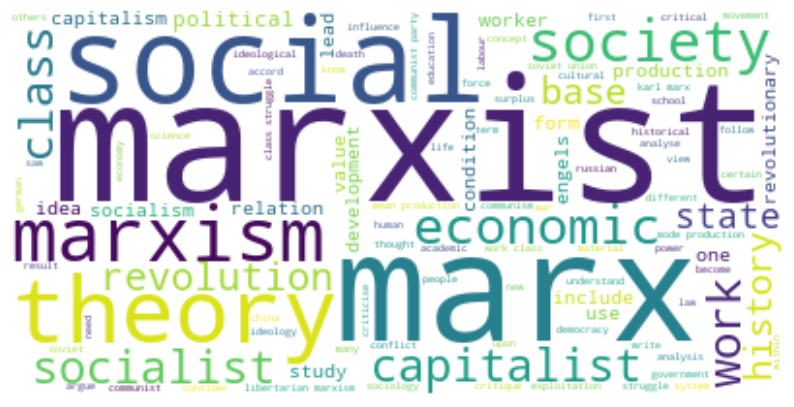

In [128]:
wc = WordCloud(max_words=1000,
               random_state=1, background_color='white').generate(text)
# show image
plt.figure(figsize=(10,15))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

## 🧮 4. Bektorizazioa. Testua $\rightarrow$ Zenbakia
Behin aurreko pausu guztiak bete direla, testua adimen artifizial modeloek prozesa dezaten datu kategorikotik (testu formatua) zenbakira pasa behar da. Bi talde nagusi desberdin daitezke:
1. NLP klasikoa (ML):
    - TF-IDF
    - Word2Vec
    - bag-of-words
2. Deep Learning (Transformer):
    - BERT embedding (Gaur egun erabiliena) eta deribatuak
    - GPT embedding

In [129]:
# hasierako inportak
from gensim.models import Word2Vec

In [130]:
model = Word2Vec(
    sentences=lemmatized_token,
    vector_size=100,     # dimensionality of word vectors
    window=5,            # context window size
    min_count=1,         # ignore words with total freq < min_count
    workers=4,           # parallel training
    sg=1                 # 1 = skip-gram; 0 = CBOW
)

# Build the vocabulary and train
model.train(lemmatized_token, total_examples=len(lemmatized_token), epochs=20)

(74820, 84180)

### 4.1. Egindakoaren frogapena

In [131]:
# bi hitzen arteko similaritatea float bueltatzen du
try:
    similarity_m_e = model.wv.similarity('marx', 'engels')
    print(f" 'marx' and 'engels' arteko similaritatea: {similarity_m_e:.4f}")
except KeyError as e:
    print(f"KeyError: {e}")

print('|------------------|')

# Most similar words to 'marx' lista bueltatzen du (hitza,probabilitatea)
try:
    similar_words_marx = model.wv.most_similar('marx', topn=5)
    print("Most similar words to 'marx':")
    print(*similar_words_marx, sep='\n')
except KeyError as e:
    print(f"KeyError: {e}")

 'marx' and 'engels' arteko similaritatea: 0.9804
|------------------|
Most similar words to 'marx':
('friedrich', 0.9866287708282471)
('karl', 0.9846145510673523)
('engels', 0.9804051518440247)
('later', 0.9682923555374146)
('write', 0.9649761319160461)


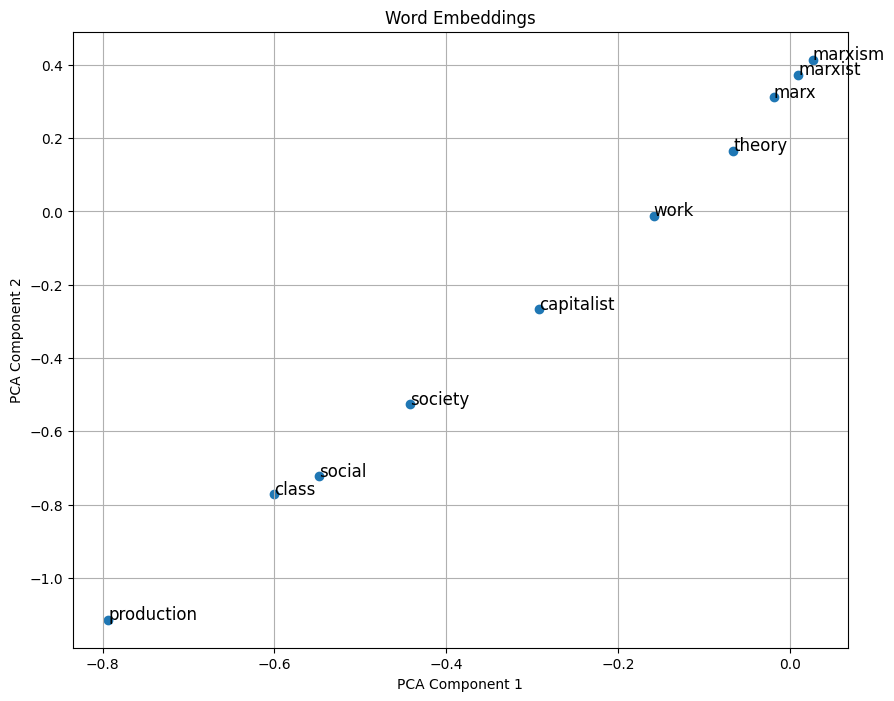

In [132]:
from sklearn.decomposition import PCA

word_vectors = model.wv[model.wv.index_to_key]  # Get the word vectors
pca = PCA(n_components=2)  # Initialize PCA
result = pca.fit_transform(word_vectors)  # Fit and transform the word vectors
result = result[0:10]

# Plot the words in a 2D space
plt.figure(figsize=(10, 8))
plt.scatter(result[:, 0], result[:, 1])

# Annotate words in the plot
words = list(model.wv.index_to_key)
words = words[0:10]
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]), fontsize=12)

plt.title("Word Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.ion()
plt.show()

### 4.2. Dokumentua $\rightarrow$ Bektorea

In [133]:
import numpy as np

def doc_vector(tokens, model):
    # Keep only words that exist in the model vocabulary
    valid_words = [w for w in tokens if w in model.wv.key_to_index]

    if not valid_words:
        return np.zeros(model.vector_size)

    return np.mean(model.wv[valid_words], axis=0)

X = np.vstack([doc_vector(doc, model) for doc in lemmatized_token])

In [134]:
X

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.00914737,  0.23717114, -0.1209531 , ..., -0.18715717,
         0.05832691,  0.03096929],
       [ 0.03013037,  0.21440852, -0.05472027, ..., -0.18578246,
         0.0738012 ,  0.0243504 ],
       ...,
       [-0.01353792,  0.21083367, -0.05384569, ..., -0.20310305,
         0.04737767,  0.01808797],
       [-0.02933121,  0.19380312, -0.07649092, ..., -0.19577254,
         0.06522205,  0.01441925],
       [-0.02126018,  0.18833175, -0.0768538 , ..., -0.18612044,
         0.06184898,  0.01366392]], shape=(84, 100))